In [34]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
np.random.seed(110)
# Generate data
red = np.random.normal(3, 0.8, 40)
blue = np.random.normal(7, 0.4, 40)
data = np.sort(np.concatenate((red, blue)))
# Initial guesses
mu1, mu2 = 2.1, 6 ##means
sigma1, sigma2 = 1.5, 0.8 ## std_deviations

print(data)

[0.89512311 1.67087557 1.7617658  1.78500862 1.8258919  2.0051877
 2.30534419 2.32497804 2.34755086 2.36304116 2.38692906 2.40406571
 2.40926309 2.41222868 2.45195997 2.48115371 2.61455321 2.69846263
 2.82109004 2.86972785 2.95281751 3.0217275  3.03749356 3.08376951
 3.10408746 3.12563731 3.16964252 3.1944013  3.26287768 3.34513789
 3.4300685  3.45043558 3.85543983 3.91817812 3.93338424 4.12249906
 4.25219328 4.25302447 4.26244185 4.4352071  6.07251891 6.09966535
 6.38100538 6.38902074 6.53669549 6.568839   6.67321592 6.72632946
 6.72954806 6.81690201 6.82151984 6.82650335 6.83602835 6.83910417
 6.86717942 6.87871803 6.89066472 6.8992369  6.92474394 6.94083691
 6.98696776 6.99228361 7.02550582 7.03471346 7.04416833 7.04673171
 7.16880929 7.17554704 7.19063995 7.22098557 7.27483991 7.29678324
 7.30981141 7.31217921 7.36440317 7.39261991 7.45316237 7.46406371
 7.50177677 7.77421144]


In [35]:
for _ in range(100):
    #E step
    p1=norm.pdf(data,mu1,sigma1)
    p2=norm.pdf(data,mu2,sigma2)
    w1=p1/(p1+p2)
    w2=p2/(p1+p2)

    ## M step
    mu1=np.sum(w1*data)/np.sum(w1)
    mu2=np.sum(w2*data)/np.sum(w2)
    sigma1=np.sqrt(np.sum(w1*(data-mu1)**2)/np.sum(w1))
    sigma2=np.sqrt(np.sum(w2*(data-mu2)**2)/np.sum(w2))

Cluster 1: mean = 2.9018005882545093 std = 0.8138926842775278
Cluster 2: mean = 6.9688958710772475 std = 0.3645778408312219


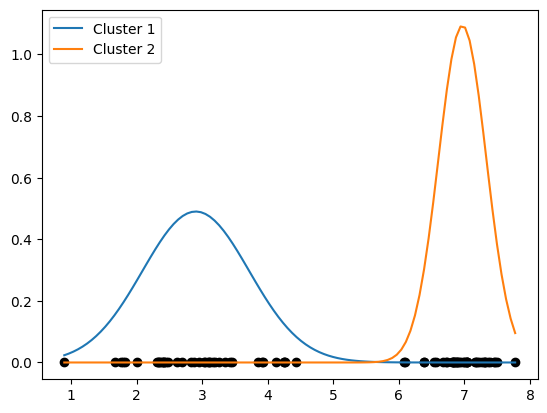

In [36]:
print("Cluster 1: mean =", mu1, "std =", sigma1)
print("Cluster 2: mean =", mu2, "std =", sigma2)
# Plot
x = np.linspace(min(data), max(data), 100)
plt.plot(x, norm.pdf(x, mu1, sigma1), label="Cluster 1")
plt.plot(x, norm.pdf(x, mu2, sigma2), label="Cluster 2")
plt.scatter(data, np.zeros_like(data), c='black')
plt.legend()
plt.show()